<a href="https://colab.research.google.com/github/gauravv-k/Voting---Ensemble-Learning-Fault-Detection-of-Motor/blob/google-Colab/Evalution_result_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q scikit-learn tensorflow matplotlib seaborn scikeras

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from scikeras.wrappers import KerasClassifier
from tensorflow.keras import layers, models
from google.colab import files


In [ ]:
# Upload files
uploaded = files.upload()

# Load datasets
main_file = input("Enter main dataset filename (e.g., motor_fault_detection_dataset.csv): ")
test_file = input("Enter test dataset filename (e.g., test_file_3.csv): ")
test_has_header = input("Does the test file have a header? (yes/no): ").strip().lower() == 'yes'

try:
    df = pd.read_csv(main_file)
    test_df = pd.read_csv(test_file, header=0 if test_has_header else None)
except Exception as e:
    raise ValueError(f"Error reading files: {e}")

# Fix columns
feature_cols = [f'F{i}' for i in range(df.shape[1] - 1)]
df.columns = feature_cols + ['Fault_Type']
test_df.columns = feature_cols


Saving motor_fault_detection_dataset.csv to motor_fault_detection_dataset (1).csv
Saving test_file_3.csv to test_file_3.csv
Enter main dataset filename (e.g., motor_fault_detection_dataset.csv): motor_fault_detection_dataset.csv
Enter test dataset filename (e.g., test_file_3.csv): test_file_3.csv
Does the test file have a header? (yes/no): no


In [ ]:

# Encode labels
label_encoder = LabelEncoder()
df['Fault_Type'] = label_encoder.fit_transform(df['Fault_Type'])

# Split features & target
X = df.drop('Fault_Type', axis=1)
y = df['Fault_Type']

In [ ]:
# Train-test split and normalization
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Define NN model function
def build_nn_model():
    model = models.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(len(np.unique(y)), activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
# KerasClassifier wrapper
nn_clf = KerasClassifier(model=build_nn_model, epochs=30, batch_size=32, verbose=0)

In [ ]:
# Other models
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)
nb_model = GaussianNB()


In [ ]:
# Fit all models
nn_clf.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
nb_model.fit(X_train, y_train)

GaussianNB()

In [ ]:

# Custom Soft Voting Ensemble (Manual)
rf_probs = rf_model.predict_proba(X_test)
dt_probs = dt_model.predict_proba(X_test)
nb_probs = nb_model.predict_proba(X_test)
nn_probs = nn_clf.predict_proba(X_test)

avg_probs = (rf_probs + dt_probs + nb_probs + nn_probs) / 4
ensemble_preds = np.argmax(avg_probs, axis=1)

In [ ]:
# Evaluation
print("\n--- MODEL PERFORMANCE ---")
models = {
    'Neural Network': nn_clf.predict(X_test),
    'Random Forest': rf_model.predict(X_test),
    'Decision Tree': dt_model.predict(X_test),
    'Naive Bayes': nb_model.predict(X_test),
    'Ensemble': ensemble_preds
}
for name, pred in models.items():
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, pred))
    print("F1 Score (Weighted):", f1_score(y_test, pred, average='weighted'))
    print("F1 Score (Per Class):", f1_score(y_test, pred, average=None))


--- MODEL PERFORMANCE ---

Neural Network
Accuracy: 1.0
F1 Score (Weighted): 1.0
F1 Score (Per Class): [1. 1. 1. 1. 1. 1.]

Random Forest
Accuracy: 1.0
F1 Score (Weighted): 1.0
F1 Score (Per Class): [1. 1. 1. 1. 1. 1.]

Decision Tree
Accuracy: 1.0
F1 Score (Weighted): 1.0
F1 Score (Per Class): [1. 1. 1. 1. 1. 1.]

Naive Bayes
Accuracy: 1.0
F1 Score (Weighted): 1.0
F1 Score (Per Class): [1. 1. 1. 1. 1. 1.]

Ensemble
Accuracy: 1.0
F1 Score (Weighted): 1.0
F1 Score (Per Class): [1. 1. 1. 1. 1. 1.]


In [ ]:
# Cross-validation
print("\n--- 5-FOLD CROSS VALIDATION (Random Forest) ---")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='accuracy')
print("CV Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))


--- 5-FOLD CROSS VALIDATION (Random Forest) ---
CV Accuracy Scores: [1. 1. 1. 1. 1.]
Mean CV Accuracy: 1.0



--- CONFUSION MATRIX ---


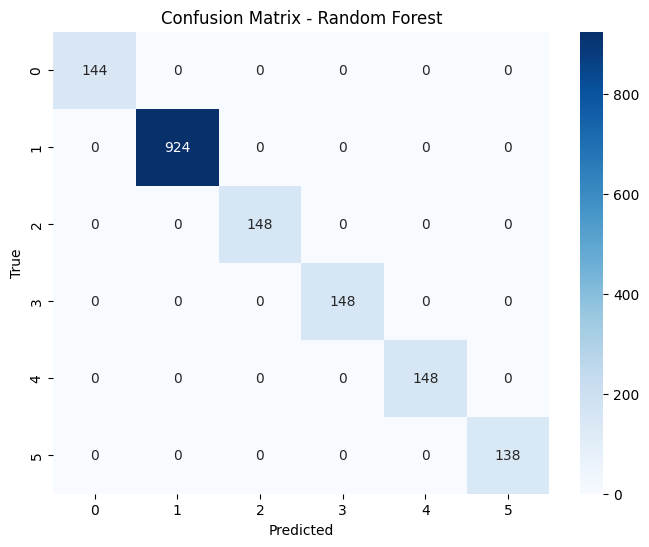

In [ ]:
# Confusion matrix
print("\n--- CONFUSION MATRIX ---")
conf_matrix = confusion_matrix(y_test, rf_model.predict(X_test))
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [ ]:
# ROC-AUC
print("\n--- ROC-AUC SCORES (Random Forest) ---")
y_test_bin = label_binarize(y_test, classes=np.unique(y))
rf_prob = rf_model.predict_proba(X_test)
print("ROC-AUC Score (Macro):", roc_auc_score(y_test_bin, rf_prob, average='macro', multi_class='ovr'))
print("ROC-AUC Score (Micro):", roc_auc_score(y_test_bin, rf_prob, average='micro', multi_class='ovr'))



--- ROC-AUC SCORES (Random Forest) ---
ROC-AUC Score (Macro): 1.0
ROC-AUC Score (Micro): 1.0


In [ ]:
# Predict test data
print("\n--- TEST FILE PREDICTION ---")
processed_test = scaler.transform(test_df)
test_preds = rf_model.predict(processed_test)
test_labels = label_encoder.inverse_transform(test_preds)
final_output = pd.DataFrame({'Predicted_Fault': test_labels})
print(final_output.head())


--- TEST FILE PREDICTION ---
  Predicted_Fault
0   Bearing Fault
1         Healthy
2         Healthy
3         Healthy
4         Healthy



--- PREDICTION DISTRIBUTION PIE CHART ---


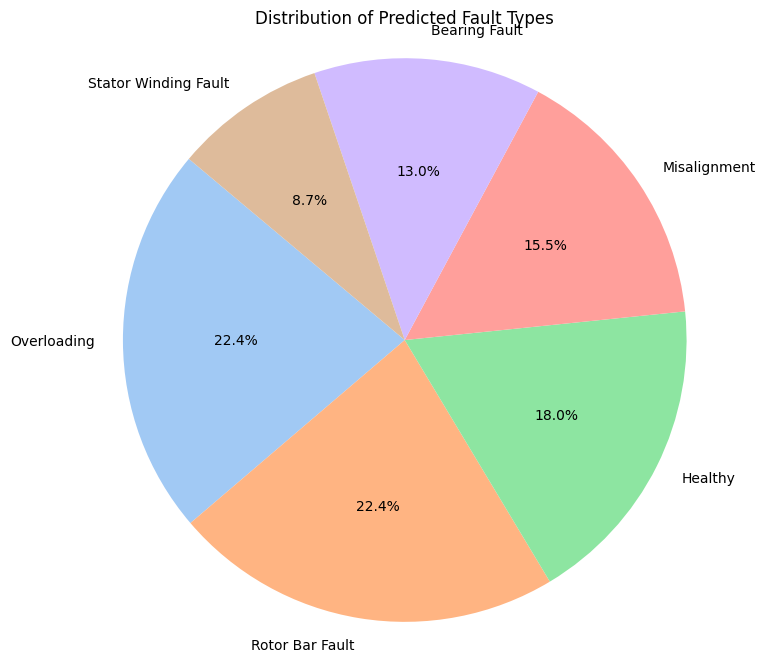

In [ ]:
# Pie chart of predicted fault types
print("\n--- PREDICTION DISTRIBUTION PIE CHART ---")
fault_counts = final_output['Predicted_Fault'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(fault_counts, labels=fault_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title("Distribution of Predicted Fault Types")
plt.axis('equal')
plt.show()


In [ ]:
# Save and download predictions
final_output.to_csv("Predicted_Faults.csv", index=False)
files.download("Predicted_Faults.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install streamlit pyngrok scikit-learn scikeras tensorflow matplotlib seaborn


In [ ]:
! pip install streamlit -q

In [ ]:
!wget -q -O - ipv4.icanhazip.com

34.57.42.168


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501